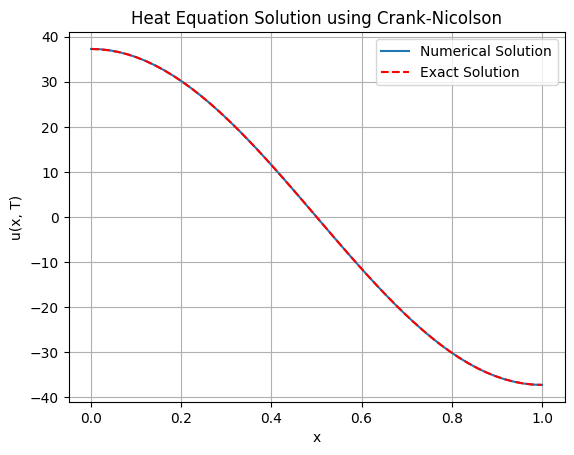

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 50       # Number of spatial points
alpha = 1    # Diffusion coefficient
L = 1        # Length of the rod
T = 0.1      # Total time
dx = L / (n - 1)  # Spatial step
dt = 0.001        # Time step
r = alpha * dt / dx**2  # Stability parameter

# Constructing matrices A and B
A = (1 + r) * np.eye(n) - (r / 2) * np.diag(np.ones(n - 1), 1) - (r / 2) * np.diag(np.ones(n - 1), -1)
B = (1 - r) * np.eye(n) + (r / 2) * np.diag(np.ones(n - 1), 1) + (r / 2) * np.diag(np.ones(n - 1), -1)

# Neumann boundary conditions
A[0, 1], A[-1, -2] = -r, -r
B[0, 1], B[-1, -2] = r, r

# Initial condition: u(x, 0) = 100 * cos(pi * x)
x = np.linspace(0, L, n)
u = 100 * np.cos(np.pi * x)

# Time-stepping loop
for _ in range(int(T / dt)):
    u = np.linalg.solve(A, B @ u)  # Solving the linear system at each time step

# Exact solution for comparison
u_exact = 100 * np.exp(-np.pi**2 * T) * np.cos(np.pi * x)

# Plotting the result
plt.plot(x, u, label='Numerical Solution')
plt.plot(x, u_exact, '--', label='Exact Solution', color='red')
plt.xlabel('x')
plt.ylabel('u(x, T)')
plt.title('Heat Equation Solution using Crank-Nicolson')
plt.legend()
plt.grid(True)
plt.show()


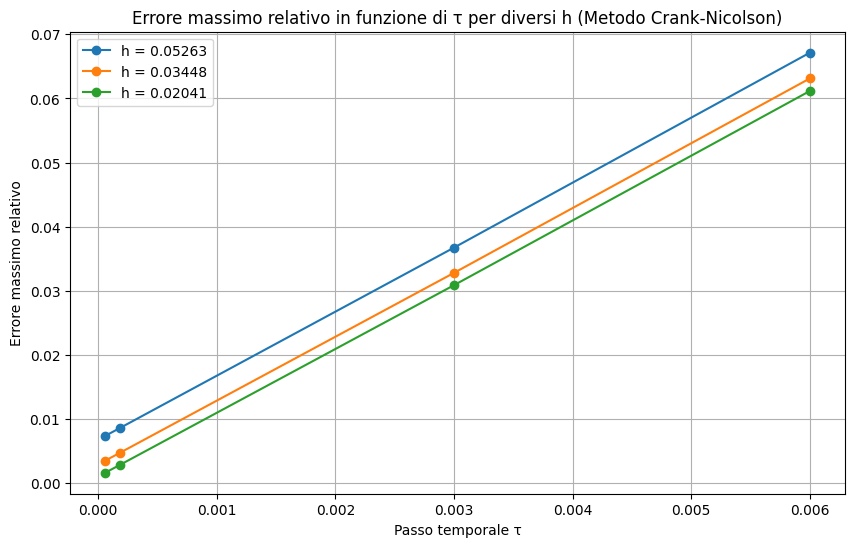

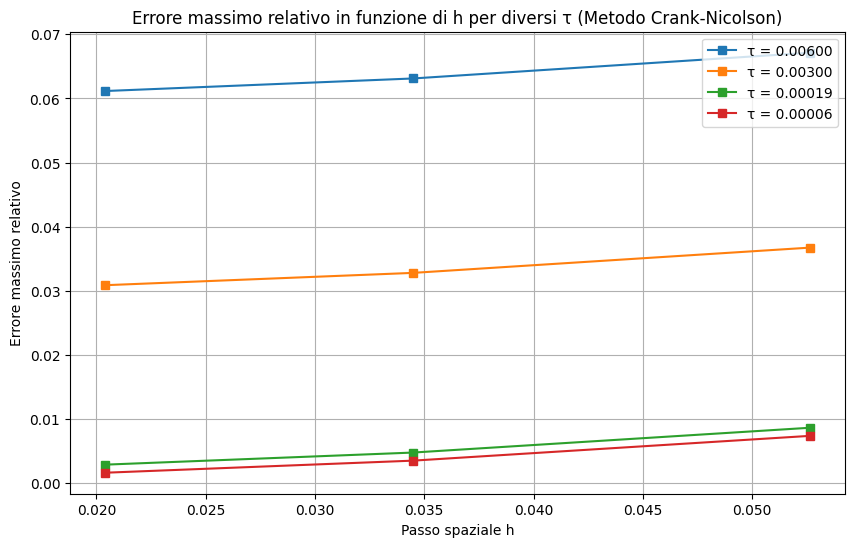

In [29]:
import numpy as np
import matplotlib.pyplot as plt

L = 1          
T = 0.3      
alpha = 1      # Coefficiente di diffusione termica

def solve_heat_equation(n, m):
    dx = L / (n - 1)  
    dt = T / m          
    r = alpha * dt / dx**2  
    
    # Griglia spaziale
    x = np.linspace(0, L, n)
    t = np.linspace(0, T, m)
    
    # Costruzione della matrice A (parte implicita)
    A = (1 + r) * np.eye(n) - (r / 2) * np.diag(np.ones(n - 1), 1) - (r / 2) * np.diag(np.ones(n - 1), -1)
    A[0, 1], A[-1, -2] = -r, -r 

    # Costruzione della matrice B (parte esplicita)
    B = (1 - r) * np.eye(n) + (r / 2) * np.diag(np.ones(n - 1), 1) + (r / 2) * np.diag(np.ones(n - 1), -1)
    B[0, 1], B[-1, -2] = r, r  

    # Condizione iniziale
    u = 100 * np.cos(np.pi * x)
    u0 = u.copy()
    max_errors = []
    
     # Loop temporale
    for j in range(m-1):
        b = u0  # posso cambiare condizioni al contorto in caso più complessi 
        ## eg: b = u0 + dt * f(x)
        u = np.linalg.solve(A, B @ b)
        u_exact = 100 * np.exp(-np.pi**2 * t[j+1]) * np.cos(np.pi * x)
        
        max_error = np.max(np.abs(u - u_exact)) / np.max(np.abs(u_exact))
        max_errors.append(max_error)
        #u_app_list.append(u.copy())
        u0 = u
    
    return max_error


n_values = [20, 30, 50]  
m_values = [50, 100, 1600, 5000] 

errors = np.zeros((len(n_values), len(m_values)))

# Calcolo dell'errore per ciascuna combinazione di n e m
for i, n in enumerate(n_values):
    for j, m in enumerate(m_values):
        errors[i, j] = solve_heat_equation(n, m)


h_values = [L / (n - 1) for n in n_values]
tau_values = [T / m for m in m_values]


# Plot dell'errore in funzione di tau per diversi h
plt.figure(figsize=(10, 6))

for i, h in enumerate(h_values):
    plt.plot(tau_values, errors[i, :], marker='o', label=f"h = {h:.5f}")

plt.xlabel("Passo temporale τ")
plt.ylabel("Errore massimo relativo")
plt.title("Errore massimo relativo in funzione di τ per diversi h (Metodo Crank-Nicolson)")
plt.legend()
plt.grid(True)
plt.show()

# Plot dell'errore in funzione di h per diversi tau
plt.figure(figsize=(10, 6))

for j, tau in enumerate(tau_values):
    plt.plot(h_values, errors[:, j], marker='s', label=f"τ = {tau:.5f}")

plt.xlabel("Passo spaziale h")
plt.ylabel("Errore massimo relativo")
plt.title("Errore massimo relativo in funzione di h per diversi τ (Metodo Crank-Nicolson)")
plt.legend()
plt.grid(True)
plt.show()
